In [5]:
import matplotlib.pyplot as plt
import numpy as np
import cv2
import sys
sys.path.append("..")
from utility import graph_coloring

In [18]:
img = cv2.imread('/DATA/vito/data/sedinet/SediNet/images/5_6.JPG')
im1 = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.imread('/DATA/vito/data/sedinet/SediNet/images/6_7.JPG')
im2 = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

im1=im1[:,:,:3]
im1_pred = (im1 == [0, 0, 0]).all(axis=-1)
im1[im1_pred] = [255, 255, 255]

im2=im2[:,:,:3]
im2_pred = (im2 == [0, 0, 0]).all(axis=-1)
im2[im2_pred] = [255, 255, 255]

im1_pred=np.load('/DATA/vito/output/Sedinet_select/sedinet_5_6.JPG_org_dw2/Merged/all_mask_merged_windows_id_001.npy')
im2_pred=np.load('/DATA/vito/output/Sedinet_select/sedinet_6_7.JPG_org_dw2/Merged/all_mask_merged_windows_id_001.npy')
im1_pred = cv2.resize(im1_pred, im1.shape[:-1][::-1], interpolation=cv2.INTER_NEAREST)
im2_pred = cv2.resize(im2_pred, im2.shape[:-1][::-1], interpolation=cv2.INTER_NEAREST)



In [19]:
im1_pred = im1_pred.astype("float")
im1_pred[im1_pred == 0] = np.nan
im1_pred = graph_coloring(im1_pred)

im2_pred = im2_pred.astype("float")
im2_pred[im2_pred == 0] = np.nan
im2_pred = graph_coloring(im2_pred)

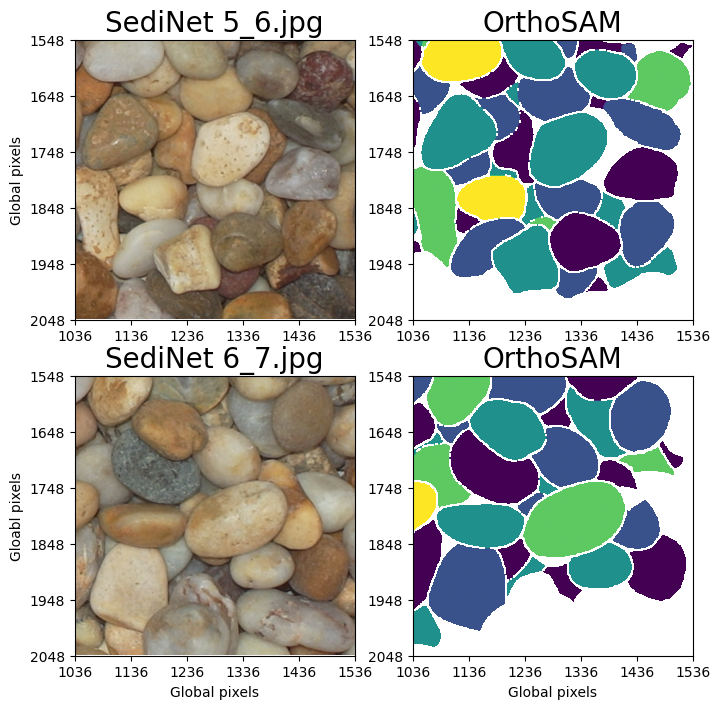

In [24]:
plt.figure(figsize=(8, 8))
plt.subplot(2,2,1)
plt.imshow(im1[-500:,-500:,:])
plt.title('SediNet 5_6.jpg', fontsize=20)
plt.ylabel('Global pixels')
xticks = plt.xticks()[0][1:]
yticks = plt.yticks()[0][1:]
xoffset, yoffset = im1.shape[0]-500, im1.shape[1]-500
plt.xticks(xticks, [int(x + xoffset) for x in xticks])
plt.yticks(yticks, [int(y + yoffset) for y in yticks])

plt.subplot(2,2,2)
#plt.imshow(im1[-500:,-500:,:])
plt.imshow(im1_pred[-500:,-500:])
plt.title('OrthoSAM', fontsize=20)
plt.xticks(xticks, [int(x + xoffset) for x in xticks])
plt.yticks(yticks, [int(y + yoffset) for y in yticks])

plt.subplot(2,2,3)
plt.imshow(im2[-500:,-500:,:])
plt.title('SediNet 6_7.jpg', fontsize=20)
plt.xlabel('Global pixels')
plt.ylabel('Gloabl pixels')
xticks = plt.xticks()[0][1:]
yticks = plt.yticks()[0][1:]
xoffset, yoffset = im2_pred.shape[0]-500, im2_pred.shape[1]-500
plt.xticks(xticks, [int(x + xoffset) for x in xticks])
plt.yticks(yticks, [int(y + yoffset) for y in yticks])

plt.subplot(2,2,4)
#plt.imshow(im2[-500:,-500:,:])
plt.imshow(im2_pred[-500:,-500:])
plt.title('OrthoSAM', fontsize=20)
plt.xlabel('Global pixels')
plt.xticks(xticks, [int(x + xoffset) for x in xticks])
plt.yticks(yticks, [int(y + yoffset) for y in yticks]);